# Mathematical Symbol Recognition with Transformer Model

This notebook implements mathematical symbol recognition from handwritten InkML stroke data using a Transformer architecture.

## Data Analysis and Model Training Pipeline

In [2]:
# Import libraries and modules
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from symbol_analyzer import SymbolDistributionAnalyzer
from statistics_calculator import StatisticsCalculator
from visualization_utils import *
from symbol_categorizer import SymbolCategorizer
from stroke_preprocessor import StrokePreprocessor
from transformer_model import StrokeTransformer, model_summary
from dataset_loader import DataManager
from trainer import StrokeTransformerTrainer

# Configure matplotlib
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("All modules imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All modules imported successfully!
PyTorch version: 2.7.0+cu118
CUDA available: True


Analyzing InkML files in: c:\Users\Pedro\Desktop\AlgebraKitStrokeRecognitionProjectTests\symbols
Directory exists: True
Parsing all InkML files...
Found 6423 InkML files
Processed 1000/6423 files...
Processed 2000/6423 files...
Processed 3000/6423 files...
Processed 4000/6423 files...
Processed 5000/6423 files...
Processed 6000/6423 files...

Completed processing:
- Total files: 6423
- Successfully parsed: 6423
- Errors: 0

=== SYMBOL DISTRIBUTION ANALYSIS ===
Total unique symbols: 229
Total samples: 6423
Average samples per symbol: 28.0

=== TOP 20 MOST FREQUENT SYMBOLS ===
\frac           :   60 samples (  0.9%)
\sqrt           :   58 samples (  0.9%)
c               :   51 samples (  0.8%)
E               :   48 samples (  0.7%)
\{              :   40 samples (  0.6%)
L               :   39 samples (  0.6%)
\}              :   39 samples (  0.6%)
G               :   39 samples (  0.6%)
M               :   39 samples (  0.6%)
[               :   39 samples (  0.6%)
N               : 

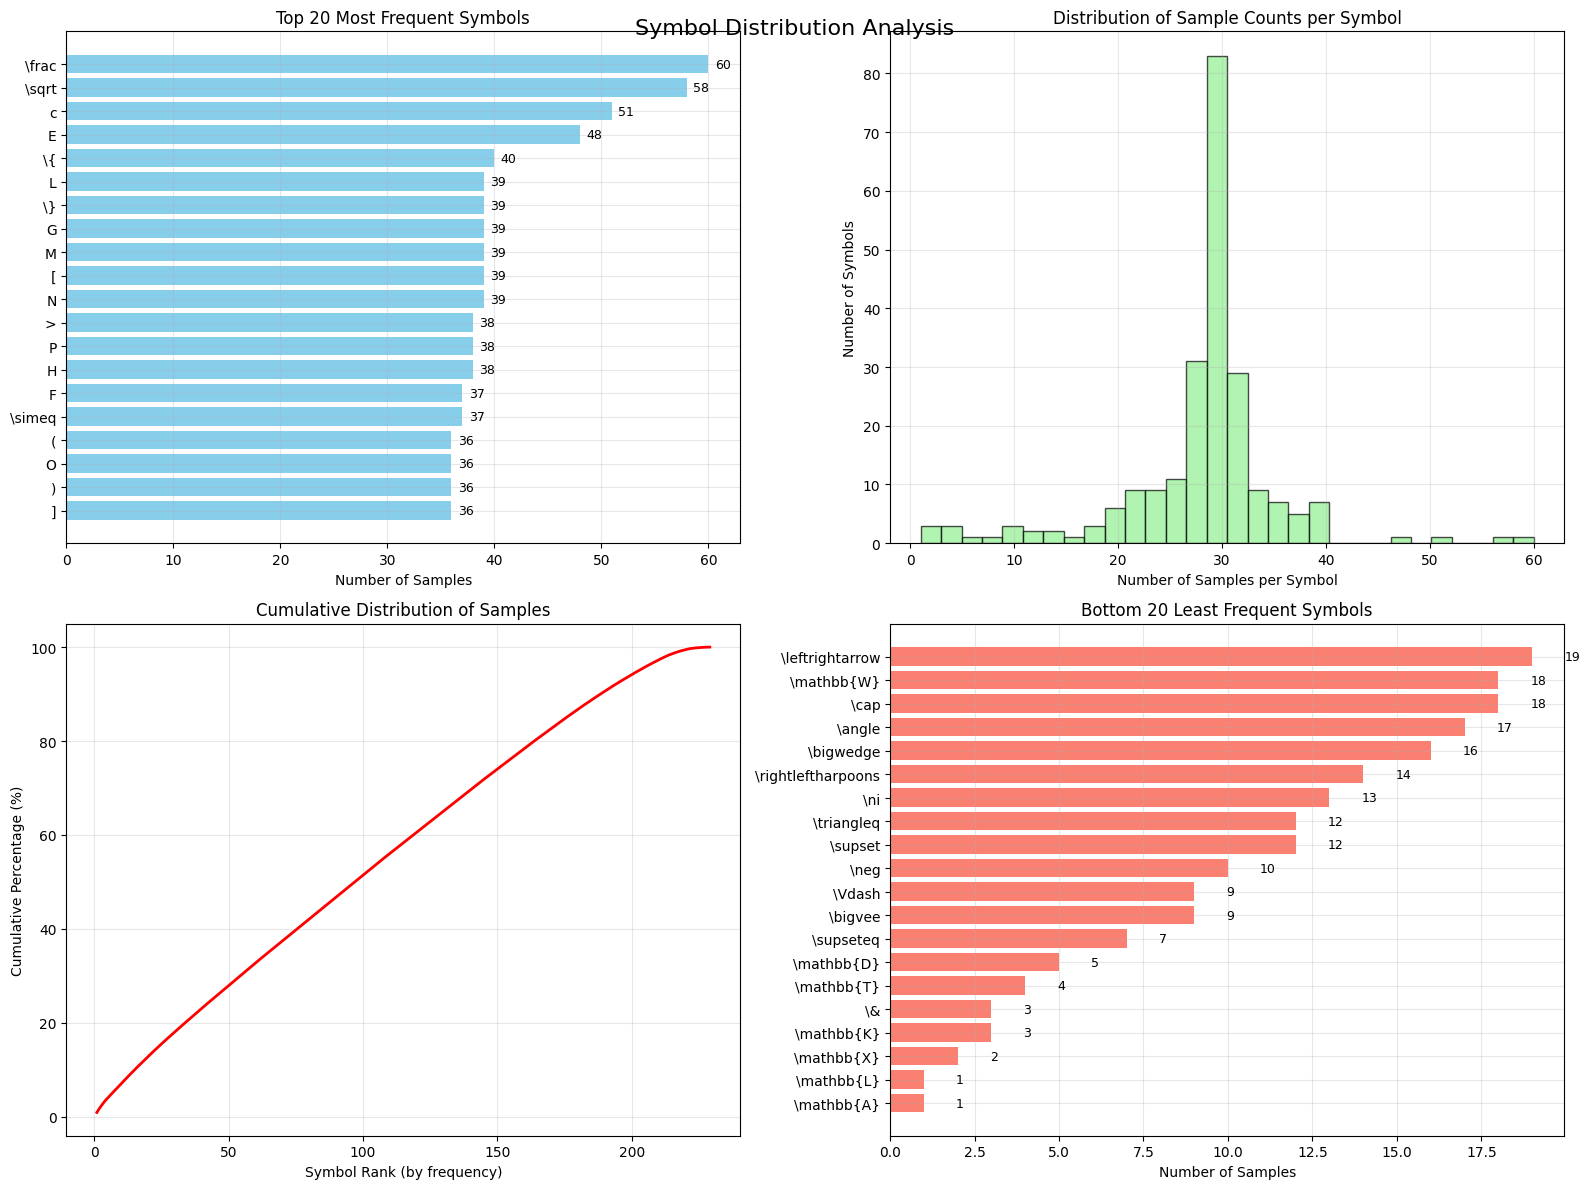

Analysis results saved to: symbols\symbol_distribution_analysis.csv


In [3]:
# Symbol Distribution Analysis
symbols_dir = Path("symbols")
analyzer = SymbolDistributionAnalyzer(symbols_dir)

print(f"Analyzing InkML files in: {symbols_dir.absolute()}")
print(f"Directory exists: {symbols_dir.exists()}")

# Run analysis and display results
symbol_counts, all_labels, total_processed = analyzer.analyze_distribution()
analyzer.print_summary()

# Statistical analysis
stats_calc = StatisticsCalculator(symbol_counts)
stats_calc.print_detailed_statistics()

# Create visualizations
fig = plot_comprehensive_analysis(symbol_counts, figsize=(16, 12))
plt.suptitle('Symbol Distribution Analysis', fontsize=16, y=0.98)
plt.show()

# Save results
csv_path = analyzer.save_results_to_csv()
print(f"Analysis results saved to: {csv_path}")

Symbol categorization analysis
Analyzing 229 unique symbols with 6423 total samples

Category Summary:
               Category  Number of Symbols  Total Samples  Percentage of Dataset  Average Samples per Symbol
      Uppercase Letters                 26            856                  13.33                       32.92
        Greek Lowercase                 27            792                  12.33                       29.33
      Lowercase Letters                 26            770                  11.99                       29.62
        Basic Operators                 19            545                   8.49                       28.68
  Brackets & Delimiters                 14            456                   7.10                       32.57
    Logic & Quantifiers                 14            338                   5.26                       24.14
        Greek Uppercase                 11            336                   5.23                       30.55
                Numbers  

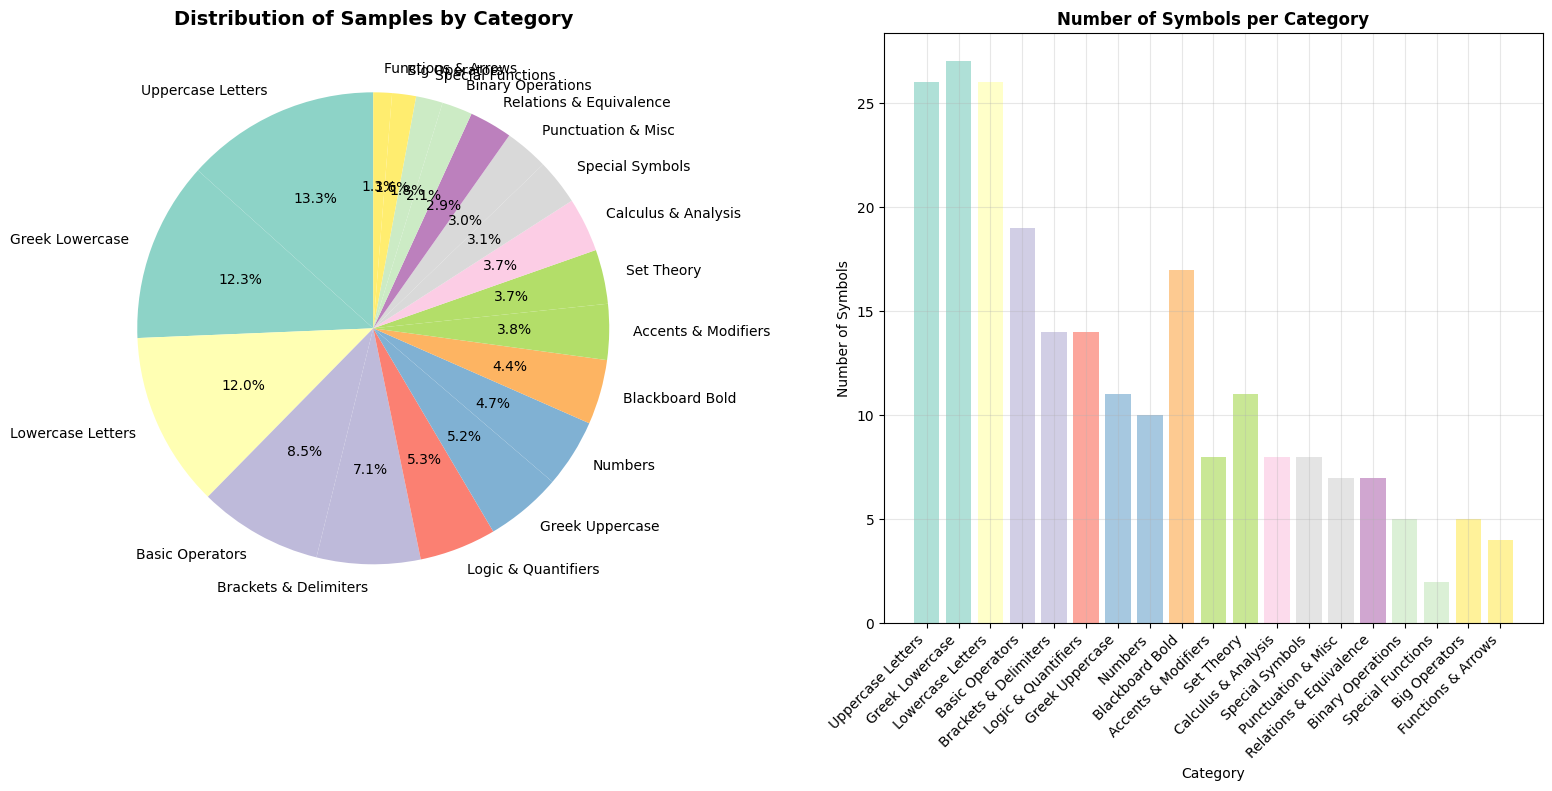


Detailed Category Breakdown:
COMPLETE CATEGORIZED SYMBOL ANALYSIS
Total unique symbols: 229
Categories found: 19

------------------------------------------------------------
SPECIAL FUNCTIONS (2 symbols, 118 samples, 1.8%)
------------------------------------------------------------
  \frac                :   60 samples ( 0.93%)
  \sqrt                :   58 samples ( 0.90%)

------------------------------------------------------------
LOWERCASE LETTERS (26 symbols, 770 samples, 12.0%)
------------------------------------------------------------
  c                    :   51 samples ( 0.79%)
  i                    :   31 samples ( 0.48%)
  r                    :   31 samples ( 0.48%)
  d                    :   30 samples ( 0.47%)
  p                    :   30 samples ( 0.47%)
  b                    :   30 samples ( 0.47%)
  n                    :   30 samples ( 0.47%)
  u                    :   30 samples ( 0.47%)
  j                    :   30 samples ( 0.47%)
  k                    

In [4]:
# Symbol Categorization Analysis
categorizer = SymbolCategorizer()
df_symbols = pd.read_csv(csv_path)

print("Symbol categorization analysis")
print(f"Analyzing {len(df_symbols)} unique symbols with {df_symbols['Count'].sum()} total samples")

# Get category summary and display
category_summary = categorizer.get_category_summary(df_symbols)
print("\nCategory Summary:")
print(category_summary.to_string(index=False, float_format='{:.2f}'.format))

# Visualize category distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Pie chart of samples by category
colors = plt.cm.Set3(np.linspace(0, 1, len(category_summary)))
ax1.pie(category_summary['Total Samples'], labels=category_summary['Category'], 
        autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Distribution of Samples by Category', fontsize=14, fontweight='bold')

# Bar chart of symbols per category
bars = ax2.bar(range(len(category_summary)), category_summary['Number of Symbols'], 
               color=colors, alpha=0.7)
ax2.set_xlabel('Category')
ax2.set_ylabel('Number of Symbols')
ax2.set_title('Number of Symbols per Category', fontweight='bold')
ax2.set_xticks(range(len(category_summary)))
ax2.set_xticklabels(category_summary['Category'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print detailed categorized analysis
print("\nDetailed Category Breakdown:")
categorizer.print_categorized_analysis(df_symbols)

In [5]:
# Data Preparation for Deep Learning
import shutil
import random

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Setup directories
cache_dir = Path("cache")
checkpoints_dir = Path("checkpoints")
cache_dir.mkdir(exist_ok=True)
checkpoints_dir.mkdir(exist_ok=True)

# Clear cache for fresh processing
if cache_dir.exists():
    shutil.rmtree(cache_dir)
cache_dir.mkdir(exist_ok=True)

print("Cache cleared. Processing datasets...")

# Initialize data manager
data_manager = DataManager(
    data_dir=symbols_dir,
    target_length=128,
    feature_dim=8,
    test_split=0.2,
    val_split=0.1,
    cache_dir=cache_dir,
    random_seed=42
)

# Prepare datasets (use full dataset)
datasets = data_manager.prepare_data()
class_info = data_manager.get_class_info()

print(f"Dataset preparation complete:")
print(f"Train: {len(datasets['train'])} samples")
print(f"Validation: {len(datasets['val'])} samples")
print(f"Test: {len(datasets['test'])} samples")
print(f"Number of classes: {class_info['num_classes']}")

# Create data loaders
loaders = data_manager.create_data_loaders(
    batch_size=16,
    num_workers=0,
    use_weighted_sampling=True
)

# Test batch
for features, labels in loaders['train']:
    print(f"Sample batch - Features: {features.shape}, Labels: {labels.shape}")
    print(f"Feature range: [{features.min():.3f}, {features.max():.3f}]")
    break

Cache cleared. Processing datasets...
Preparing datasets...
Found 6423 InkML files
Processing stroke data...


Processing files: 100%|██████████| 6423/6423 [00:07<00:00, 840.98it/s] 


Cached processed data to cache\processed_data_6423.pkl
Loaded 6423 valid samples
Number of unique classes: 229
Computing normalization statistics...
Data splits: Train=4497, Val=642, Test=1284
Dataset preparation complete:
Train: 4497 samples
Validation: 642 samples
Test: 1284 samples
Number of classes: 229
Sample batch - Features: torch.Size([16, 128, 8]), Labels: torch.Size([16])
Feature range: [-13.251, 6.523]


In [6]:
# Model Creation and Training Setup
num_classes = class_info['num_classes']

# Model configuration
model_config = {
    'input_dim': 8,
    'num_classes': num_classes,
    'd_model': 256,
    'nhead': 8,
    'num_encoder_layers': 4,
    'dim_feedforward': 1024,
    'dropout': 0.15,
    'max_len': 128,
    'pooling_type': 'attention'
}

# Create model
model = StrokeTransformer(**model_config)
print("Transformer Model Created")
print(model_summary(model, (1, 128, 8)))

# Test forward pass
test_input = torch.randn(2, 128, 8)
with torch.no_grad():
    test_output = model(test_input)
print(f"Forward pass successful - Input: {test_input.shape}, Output: {test_output.shape}")

# Setup trainer
trainer = StrokeTransformerTrainer(
    model=model,
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    test_loader=loaders['test'],
    class_weights=class_info['class_weights'],
    device='auto',
    save_dir=checkpoints_dir
)

# Configure optimizer and scheduler for extended training
trainer.configure_optimizer(optimizer_type='adamw', learning_rate=2e-4, weight_decay=0.01)
trainer.configure_scheduler(scheduler_type='cosine', T_max=200, eta_min=1e-6)  # Updated for 200 epochs

print(f"Trainer configured - Device: {trainer.device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("Configuration optimized for 200 epoch training")

Transformer Model Created

StrokeTransformer Model Summary:
Input shape: (1, 128, 8)
Total parameters: 3,250,918
Model size: ~12.40 MB (float32)

Architecture:
- Embedding: 8 -> 256
- Transformer: 4 layers
- Model dimension: 256
- Attention heads: 8
- Feed-forward dim: 1024
- Output classes: 229
- Pooling: attention



Forward pass successful - Input: torch.Size([2, 128, 8]), Output: torch.Size([2, 229])
Using device: cuda
Trainer configured - Device: cuda
Model parameters: 3,250,918
Configuration optimized for 200 epoch training


Starting training...
Training configuration: {'epochs': 500, 'early_stopping_patience': None, 'save_every': 25, 'evaluate_every': 2}
Training for full 500 epochs WITHOUT early stopping
⚠️  This will take longer but may find better solutions
Starting training...
Model has 3,250,918 trainable parameters
Early stopping completely disabled - will train for all epochs


Epoch 1: 100%|██████████| 282/282 [00:11<00:00, 24.92it/s, Loss=5.6191, Acc=0.0078]


Epoch   1/500: Train Loss: 5.4426, Train Acc: 0.0078 | Val Loss: inf, Val Acc: 0.0000 | LR: 2.00e-04 | Time: 11.32s


Validation Epoch 2: 100%|██████████| 41/41 [00:00<00:00, 103.44it/s]


Epoch   2/500: Train Loss: 5.3542, Train Acc: 0.0105 | Val Loss: 5.4694, Val Acc: 0.0016 | LR: 2.00e-04 | Time: 10.98s
New best model saved with validation accuracy: 0.0016


...

Epoch 499/500: Train Loss: 0.0399, Train Acc: 0.9824 | Val Loss: inf, Val Acc: 0.0000 | LR: 1.02e-04 | Time: 10.35s


Validation Epoch 500: 100%|██████████| 41/41 [00:00<00:00, 103.71it/s]


Epoch 500/500: Train Loss: 0.0561, Train Acc: 0.9773 | Val Loss: 11.4558, Val Acc: 0.3583 | LR: 1.00e-04 | Time: 10.76s

Evaluating final model...
Loaded checkpoint from epoch 248


Final Test Evaluation: 100%|██████████| 81/81 [00:00<00:00, 99.17it/s] 



Final Results:
Train Accuracy: 0.9787
Validation Accuracy: 0.4034
Test Accuracy: 0.3653
Test F1-Score: 0.3590
Training completed
Train Accuracy: 0.9787
Validation Accuracy: 0.4034
Test Accuracy: 0.3653
Test F1-Score: 0.3590
Best Validation Accuracy: 0.4034
Total Epochs: 248

Training Summary:
- Configured for 500 epochs
- Actually trained for 248 epochs
- Early stopping: Disabled
- Best validation accuracy: 0.4034
- Final test accuracy: 0.3653


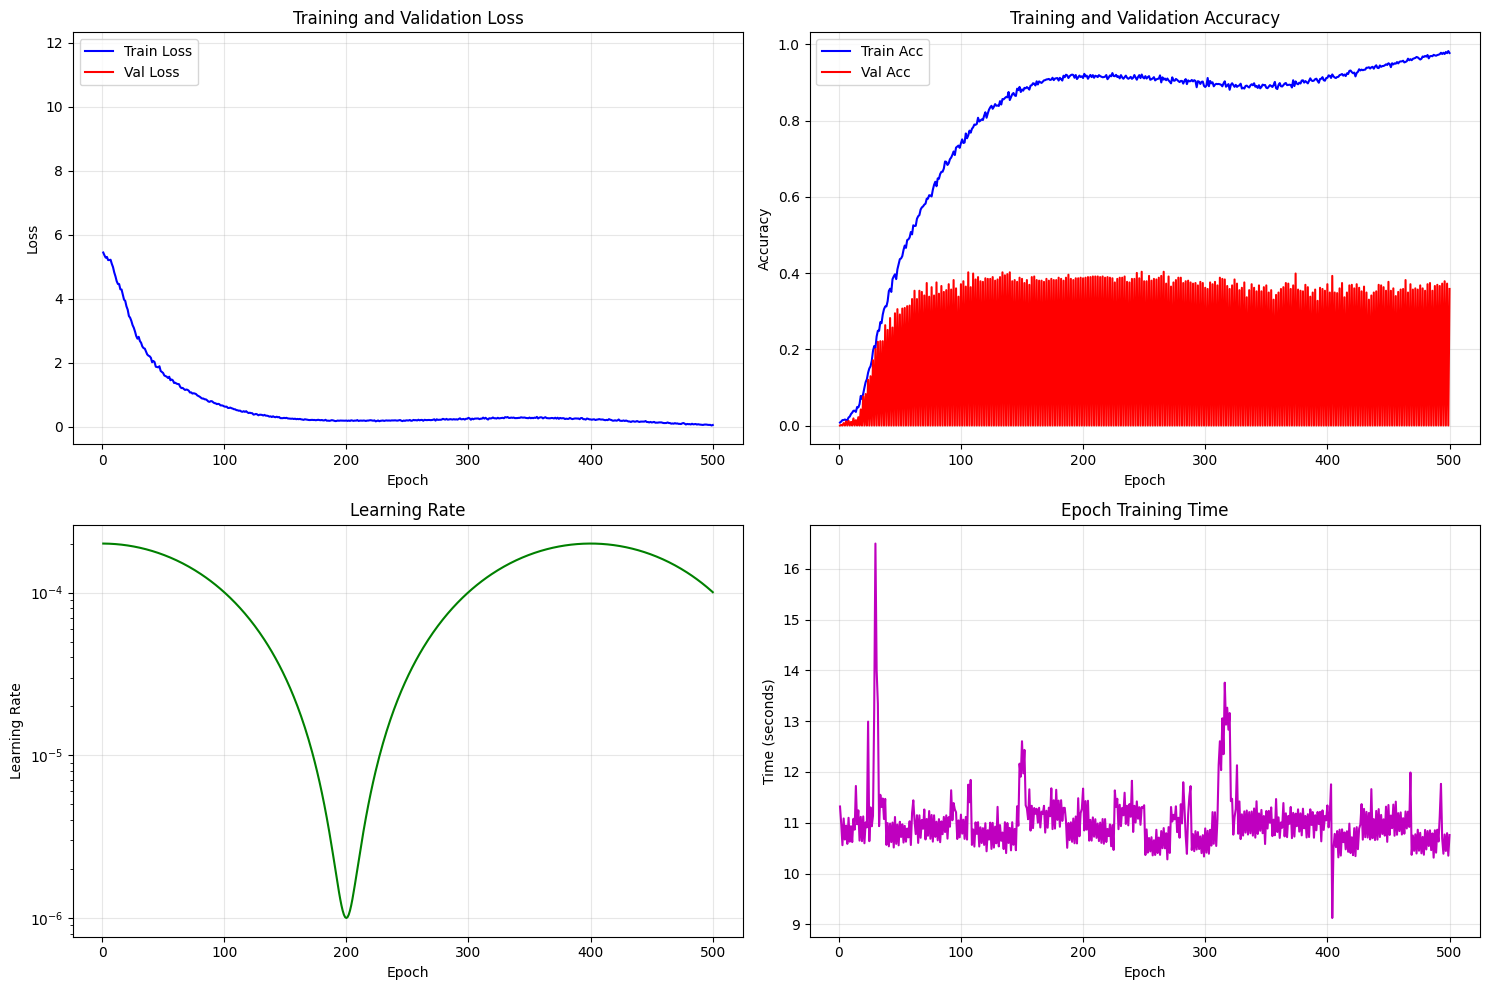

In [7]:
# Model Training
print("Starting training...")

# Training configuration - Full 500 epochs without early stopping
training_config = {
    'epochs': 500,                   # Full 500 epochs as intended
    'early_stopping_patience': None, # Disabled early stopping
    'save_every': 25,                # Save checkpoints every 25 epochs
    'evaluate_every': 2              # Evaluate every 2 epochs to save time
}

print(f"Training configuration: {training_config}")
print("Training for full 500 epochs WITHOUT early stopping")
print("⚠️  This will take longer but may find better solutions")

# Run training
training_results = trainer.train(**training_config)

# Display results
final_metrics = training_results['final_metrics']
print("Training completed")
print(f"Train Accuracy: {final_metrics['train_accuracy']:.4f}")
print(f"Validation Accuracy: {final_metrics['val_accuracy']:.4f}")
print(f"Test Accuracy: {final_metrics['test_accuracy']:.4f}")
print(f"Test F1-Score: {final_metrics['test_detailed_metrics']['weighted_f1']:.4f}")
print(f"Best Validation Accuracy: {training_results['best_val_accuracy']:.4f}")
print(f"Total Epochs: {training_results['total_epochs']}")

# Performance summary
print(f"\nTraining Summary:")
print(f"- Configured for {training_config['epochs']} epochs")
print(f"- Actually trained for {training_results['total_epochs']} epochs")

# Handle early stopping display
if training_config['early_stopping_patience'] is None:
    early_stopping_text = "Disabled"
else:
    early_stopping_text = f"{training_config['early_stopping_patience']} epochs"
print(f"- Early stopping: {early_stopping_text}")

print(f"- Best validation accuracy: {training_results['best_val_accuracy']:.4f}")
print(f"- Final test accuracy: {final_metrics['test_accuracy']:.4f}")

In [8]:
# Fixed InkML Inference - Ready to Use!

# ==========================================
# CHANGE THIS PATH TO YOUR INKML FILE
# ==========================================
your_inkml_file = "symbols/02b49e294144c958.inkml"  # Change this path!

# Import required modules with explicit reloading
try:
    from pathlib import Path
    import torch
    import numpy as np
    
    # Force reload of modules to ensure latest changes
    import importlib
    import sys
    
    if 'inkml_parser' in sys.modules:
        importlib.reload(sys.modules['inkml_parser'])
    if 'stroke_preprocessor' in sys.modules:
        importlib.reload(sys.modules['stroke_preprocessor'])
    
    from inkml_parser import InkMLParser
    from stroke_preprocessor import StrokePreprocessor
    from transformer_model import StrokeTransformer
    print("✅ All modules imported successfully")
except ImportError as e:
    print(f"❌ Import Error: {e}")
    print("Please make sure all Python modules are available")
except Exception as e:
    print(f"❌ Error: {e}")

def quick_predict(file_path):
    """Simple function to predict an InkML file"""
    print(f"Predicting: {file_path}")
    print("-" * 50)
    
    # Check if file exists
    if not Path(file_path).exists():
        print(f"❌ File not found: {file_path}")
        print("Please check the path and try again")
        return
    
    # Check for required variables from training
    required_vars = ['model', 'class_info']
    missing = []
    
    for var in required_vars:
        if var not in globals():
            missing.append(var)
    
    if missing:
        print(f"❌ Missing variables: {missing}")
        print("Please run cells 1-6 to train the model first")
        return
    
    # Initialize preprocessor with correct parameters
    try:
        preprocessor = StrokePreprocessor(target_length=128, feature_dim=8)
        print("✅ Preprocessor initialized")
    except Exception as e:
        print(f"❌ Failed to initialize preprocessor: {e}")
        return
    
    # Load best model
    checkpoints_dir = Path("checkpoints")
    if checkpoints_dir.exists() and (checkpoints_dir / "best_model.pth").exists():
        try:
            checkpoint = torch.load(checkpoints_dir / "best_model.pth", map_location='cpu')
            model.load_state_dict(checkpoint['model_state_dict'])
            print(f"✅ Model loaded (val acc: {checkpoint.get('best_val_acc', 0):.3f})")
        except Exception as e:
            print(f"⚠️  Warning: Could not load checkpoint: {e}")
            print("Using current model state")
    
    # Parse InkML file
    try:
        # Import here to ensure fresh import
        from inkml_parser import InkMLParser
        parser = InkMLParser()
        strokes, true_label = parser.parse_file(file_path)
        
        if not strokes:
            print("❌ No strokes found in file")
            return
        
        print(f"✅ Parsed {len(strokes)} strokes from InkML file")
        
        # Preprocess
        features = preprocessor.preprocess_strokes(strokes)
        if features is None:
            print("❌ Preprocessing failed")
            return
        
        print(f"✅ Features extracted: {features.shape}")
        
        # Predict
        model.eval()
        device = 'cuda' if torch.cuda.is_available() and next(model.parameters()).is_cuda else 'cpu'
        
        with torch.no_grad():
            input_tensor = torch.FloatTensor(features).unsqueeze(0).to(device)
            logits = model(input_tensor)
            probs = torch.softmax(logits, dim=-1)
            
            # Get top predictions
            top5_probs, top5_indices = torch.topk(probs[0], k=5)
            
            # Map indices to labels
            idx_to_label = {idx: label for label, idx in class_info['label_encoder'].items()}
            
            # Results
            predicted = idx_to_label[top5_indices[0].item()]
            confidence = top5_probs[0].item()
            
            print(f"✅ Prediction complete!")
            print(f"📁 File: {Path(file_path).name}")
            
            if true_label:
                print(f"🎯 True Label: {true_label}")
                print(f"🤖 Predicted: {predicted}")
                correct = predicted == true_label
                print(f"✅ Correct: {'Yes' if correct else 'No'}")
                if not correct:
                    print(f"❌ Mismatch: predicted '{predicted}' vs true '{true_label}'")
            else:
                print(f"🤖 Predicted: {predicted}")
            
            print(f"📊 Confidence: {confidence:.1%}")
            
            print(f"\n📈 Top 5 predictions:")
            for i, (prob, idx) in enumerate(zip(top5_probs, top5_indices)):
                symbol = idx_to_label[idx.item()]
                bar = "█" * max(1, int(prob.item() * 20))
                print(f"  {i+1}. {symbol:>12} {prob.item():.1%} {bar}")
                
    except Exception as e:
        print(f"❌ Error during prediction: {e}")
        import traceback
        traceback.print_exc()

# Run prediction
print("🚀 Starting inference...")
quick_predict(your_inkml_file)

print("\n" + "="*50)
print("💡 To predict different files:")
print("   1. Change 'your_inkml_file' path above")
print("   2. Run this cell again")
print("="*50)

✅ All modules imported successfully
🚀 Starting inference...
Predicting: symbols/02b49e294144c958.inkml
--------------------------------------------------
✅ Preprocessor initialized
✅ Model loaded (val acc: 0.403)
✅ Parsed 1 strokes from InkML file
✅ Features extracted: (128, 8)
✅ Prediction complete!
📁 File: 02b49e294144c958.inkml
🎯 True Label: r
🤖 Predicted: q
✅ Correct: No
❌ Mismatch: predicted 'q' vs true 'r'
📊 Confidence: 99.3%

📈 Top 5 predictions:
  1.            q 99.3% ███████████████████
  2.            d 0.5% █
  3.      \bullet 0.1% █
  4.        \cdot 0.1% █
  5.           \{ 0.1% █

💡 To predict different files:
   1. Change 'your_inkml_file' path above
   2. Run this cell again
